In [1]:
from cytetype import CyteType
import scanpy as sc

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [2]:
adata = sc.read_h5ad('../../data/talbot_xenium_tumor.h5ad')

In [8]:
adata.obs.genotype

output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaachibf-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaadbpmc-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaagejpm-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaagiphc-1      Pdl1_wt
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaahpgfk-1      Pdl1_wt
                                                                      ...   
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oikfjlfk-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilbhfce-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilfjaec-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilfkjkg-1    Pdl1_cre
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilnplad-1    Pdl1_cre
Name: genotype, Length: 207468, dtype: category
Categories (5, object): ['Oprl1_cre', 'Oprl1_wt', 'Pdl1_cre', 'Pdl1_wt', 'c57']

In [3]:
adata.var = adata.var.reset_index()

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [4]:
adata.var['gene_symbols'] = adata.var['index']

In [5]:
adata.var['gene_symbols']

0         A1cf
1          A2m
2         Aatf
3        Abca1
4       Abca13
         ...  
5001    Zswim9
5002      Zup1
5003       Zyx
5004     Zzef1
5005         a
Name: gene_symbols, Length: 5006, dtype: object

In [6]:
adata.var = adata.var.set_index('index')

In [9]:
study_context = (
    "Mouse melanoma tissue profiled with the Xenium platform to resolve the spatial organization of tumor, stromal, "
    "and immune cell populations. The dataset includes multiple genotypes—Oprl1_cre, Oprl1_wt, Pdl1_cre, Pdl1_wt, "
    "and C57—representing genetic backgrounds relevant to immune checkpoint regulation and tumor–immune interactions. "
    "This study enables spatially resolved analysis of gene expression, cell–cell communication, and microenvironmental "
    "differences across melanoma genotypes."
)

In [10]:
# ------ CyteType ------
annotator = CyteType(adata, group_key="leiden_2")
adata = annotator.run(
    study_context=study_context,
)


Using coordinates from 'X_umap' for visualization.
Calculating expression percentages.
Extracting marker genes.
Preparing visualization data with sampling.
Sampled 1000 cells from group '3' (originally 10997 cells)
Sampled 1000 cells from group '15' (originally 5526 cells)
Sampled 1000 cells from group '32' (originally 1429 cells)
Sampled 1000 cells from group '5' (originally 9975 cells)
Sampled 1000 cells from group '7' (originally 8412 cells)
Sampled 1000 cells from group '10' (originally 7611 cells)
Sampled 1000 cells from group '23' (originally 3859 cells)
Sampled 1000 cells from group '8' (originally 7772 cells)
Sampled 1000 cells from group '1' (originally 14682 cells)
Sampled 1000 cells from group '24' (originally 3164 cells)
Sampled 1000 cells from group '31' (originally 1432 cells)
Sampled 1000 cells from group '27' (originally 2245 cells)
Sampled 1000 cells from group '26' (originally 2442 cells)
Sampled 1000 cells from group '14' (originally 6442 cells)
Sampled 1000 cells fr

AttributeError: 'DataFrame' object has no attribute 'cytetype_annotation_clusters'

In [11]:
adata.obs['cytetype_annotation_leiden_2']

output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaachibf-1                      Epithelioid Melanoma Cell
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaadbpmc-1                      Epithelioid Melanoma Cell
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaagejpm-1                      Epithelioid Melanoma Cell
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaagiphc-1                      Epithelioid Melanoma Cell
output-XETG00045__0059973__Pdl1_wt__20250725__091031_aaahpgfk-1                      Epithelioid Melanoma Cell
                                                                                       ...                    
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oikfjlfk-1    Tumor-Associated Macrophage (M2-polarized)
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilbhfce-1     Outer Root Sheath Cell (Sox9+, quiescent)
output-XETG00045__0059973__Pdl1_cre__20250725__091031_oilfjaec-1             Perivascular Fibroblast-Like Cell
o

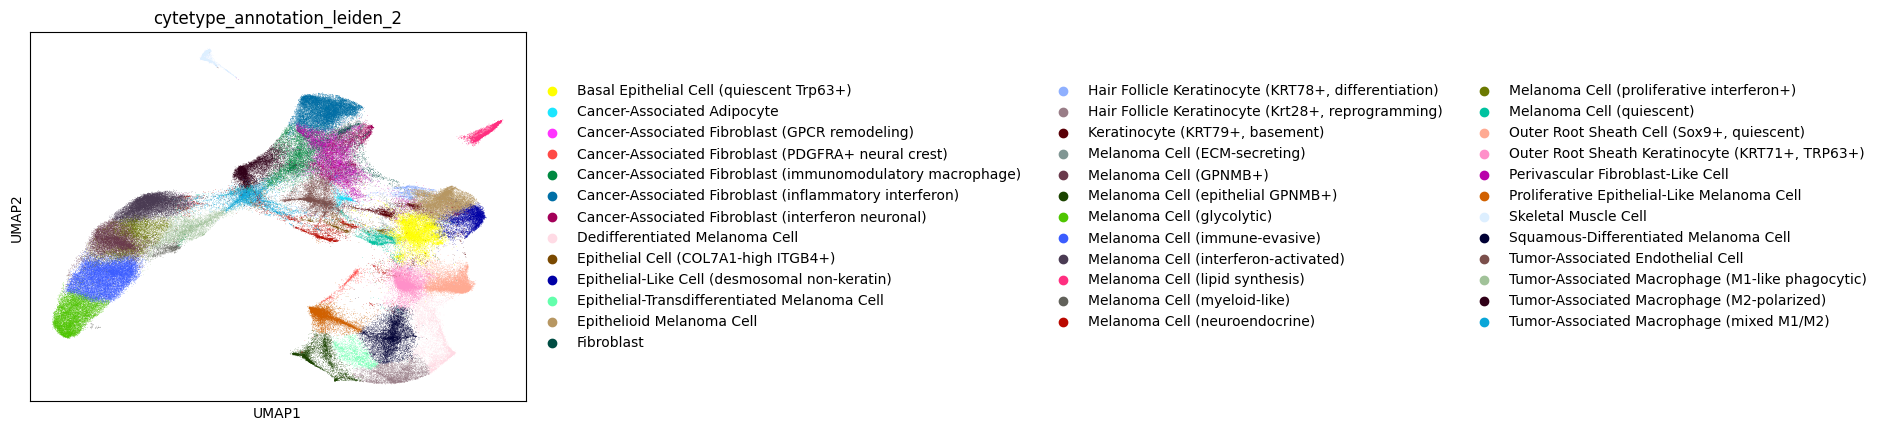

In [12]:
sc.pl.umap(adata, color = 'cytetype_annotation_leiden_2')

In [23]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors
import warnings
warnings.filterwarnings("ignore")


def plot_spatial_compact_fast(
    ad,
    color="leiden_2",
    groupby="sample_id",
    spot_size=8,
    cols=3,
    height=8,
    legend_col_width=1.2,
    palette=None,            # dict {cat:"#hex"} or list
    rasterized=True,         # big speedup for vectors/PDFs
    invert_y=True,           # match Scanpy orientation
    dpi=120,                 # lower dpi → faster
):
    # ----- 0) Preconditions -----
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")

    coords = np.asarray(ad.obsm["spatial"])[:, :2]
    cats = ad.obs[color].astype("category")
    cat_names = cats.cat.categories
    cat_codes = cats.cat.codes.to_numpy()  # -1 for NaN

    # ----- 1) Build shared palette (RGBA array) -----
    if isinstance(palette, dict):
        col_list = [palette[c] for c in cat_names]
    elif isinstance(palette, (list, tuple)):
        if len(palette) < len(cat_names):
            raise ValueError("Palette shorter than number of categories.")
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns:
        col_list = list(ad.uns[f"{color}_colors"])
        if len(col_list) != len(cat_names):
            raise ValueError(f"{color}_colors length != categories.")
    else:
        base = getattr(getattr(__import__("scanpy").pl.palettes, "default_64", []), "__iter__", None)
        base = list(__import__("scanpy").pl.palettes.default_64
                    if hasattr(__import__("scanpy").pl.palettes, "default_64")
                    else __import__("scanpy").pl.palettes.default_102)
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    # store for consistency elsewhere
    ad.uns[f"{color}_colors"] = col_list

    # convert to RGBA float array for fast indexing
    rgba = np.array([mcolors.to_rgba(c) for c in col_list], dtype=float)
    # map codes -> rgba; handle -1 (NaN) as transparent
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[cat_codes >= 0] = rgba[cat_codes[cat_codes >= 0]]
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # ----- 2) Precompute group indices (no per-iteration masks) -----
    gvals = ad.obs[groupby].astype(str).to_numpy()
    uniq_groups, gcodes = np.unique(gvals, return_inverse=True)
    # list of index arrays per group
    group_indices = [np.flatnonzero(gcodes == gi) for gi in range(len(uniq_groups))]

    # ----- 3) Figure layout -----
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w + legend_col_width

    plt.ioff()  # speed: disable interactive redraws
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(
        rows, cols + 1, figure=fig,
        width_ratios=[1]*cols + [legend_col_width / (fig_w - legend_col_width)],
        wspace=0.02, hspace=0.02
    )

    # ----- 4) Panels (fast scatter) -----
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])

        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            # note: turn off edgecolor & use rasterized for speed
            sca = ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(str(sid), fontsize=6, pad=2)
        ax.set_aspect("equal")
        if invert_y:
            ax.invert_yaxis()
        ax.set_axis_off()

    # blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    # ----- 5) Legend (single, shared) -----
    ax_leg = fig.add_subplot(gs[:, -1])
    ax_leg.axis("off")
    handles = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=col_list[k], markersize=7, label=str(cat))
        for k, cat in enumerate(cat_names)
    ]
    ax_leg.legend(handles=handles, title=color, frameon=False, loc="center left")

    fig.subplots_adjust(left=0.01, right=0.98, top=0.98, bottom=0.02, wspace=0.02, hspace=0.02)
    plt.ion()  # ✅ correct
    plt.show()

Plotting cytetype_annotation_leiden_2 …


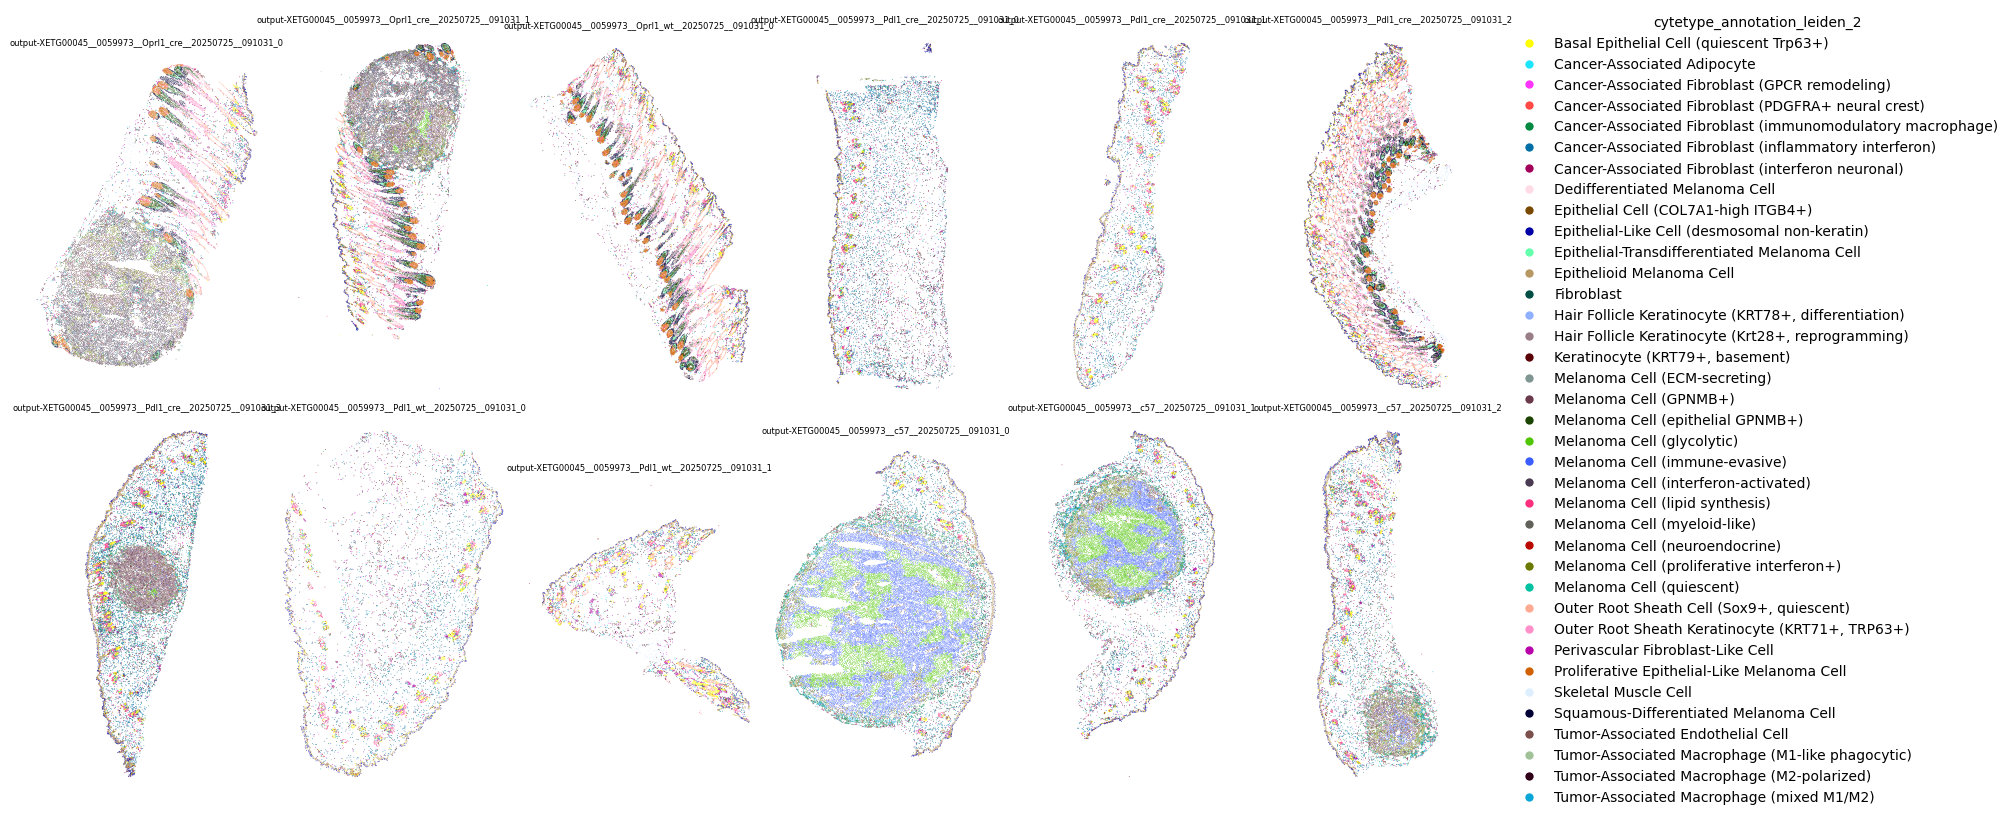

In [24]:
for domain in ['cytetype_annotation_leiden_2']:
    if domain in adata.obs.columns:
        print(f"Plotting {domain} …")
        plot_spatial_compact_fast(
            adata,
            color=domain,
            groupby="sample_id",
            spot_size=0.3,
            cols=6,
            height=8,
            legend_col_width=1.0,
            rasterized=True,   # big speedup for large data
            dpi=100             # lower = faster preview
        )
    else:
        print(f"Skipping {domain} — not in adata.obs")

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors

def plot_spatial_highlight(
    ad,
    color,                      # obs column with categories
    highlight,                  # one category to highlight
    groupby="sample_id",
    spot_size=12,
    cols=3,
    height=7,
    flip_y=True,
    fix_limits=True,            # same axes for all panels
    base_color="#B0B0B0",       # de-emphasized others
    base_alpha=0.15,
    palette=None,               # dict {cat:"#hex"} or list; if None try ad.uns[f"{color}_colors"]
    rasterized=True,
    dpi=120,
):
    if "spatial" not in ad.obsm:
        raise ValueError("ad.obsm['spatial'] is required.")
    coords = np.asarray(ad.obsm["spatial"])[:, :2]

    # categories & palette
    cats = ad.obs[color].astype("category")
    cat_names = list(cats.cat.categories)
    if isinstance(palette, dict):
        col_list = [palette.get(c, "#377eb8") for c in cat_names]
    elif isinstance(palette, (list, tuple)) and len(palette) >= len(cat_names):
        col_list = list(palette)[:len(cat_names)]
    elif f"{color}_colors" in ad.uns and len(ad.uns[f"{color}_colors"]) == len(cat_names):
        col_list = list(ad.uns[f"{color}_colors"])
    else:
        # fallback: simple cycle
        from scanpy.pl import palettes
        base = palettes.default_64 if hasattr(palettes, "default_64") else palettes.default_102
        reps = int(np.ceil(len(cat_names) / len(base)))
        col_list = (base * reps)[:len(cat_names)]

    # pick highlight color
    if highlight not in cat_names:
        raise ValueError(f"'{highlight}' not found in ad.obs['{color}'] categories.")
    h_idx = cat_names.index(highlight)
    hl_hex = col_list[h_idx]
    hl_rgba = np.array(mcolors.to_rgba(hl_hex), float)

    # precompute color array: highlight vs base
    base_rgba = np.array(mcolors.to_rgba(base_color), float)
    base_rgba[3] = base_alpha

    cat_codes = cats.cat.codes.to_numpy()  # -1 for NaN
    is_highlight = (cat_codes == h_idx)
    # initialize all as base, then overwrite highlights
    colors_arr = np.empty((cat_codes.size, 4), dtype=float)
    colors_arr[:] = base_rgba
    colors_arr[is_highlight] = hl_rgba
    # transparent for NaN
    colors_arr[cat_codes < 0] = (0, 0, 0, 0)

    # group indices (preserve observed order if possible)
    gseries = ad.obs[groupby]
    if pd.api.types.is_categorical_dtype(gseries):
        uniq_groups = list(gseries.cat.categories)
        # keep only those present
        uniq_groups = [g for g in uniq_groups if (gseries == g).any()]
        gcodes = pd.Categorical(gseries, categories=uniq_groups, ordered=True).codes
    else:
        uniq_groups = list(pd.unique(gseries))  # preserves first-appearance order
        mapping = {g:i for i,g in enumerate(uniq_groups)}
        gcodes = gseries.map(mapping).to_numpy()
    group_indices = [np.flatnonzero(gcodes == i) for i in range(len(uniq_groups))]

    # common limits (global) if requested
    if fix_limits:
        x_min, y_min = coords.min(axis=0)
        x_max, y_max = coords.max(axis=0)

    # layout
    n = len(uniq_groups)
    rows = int(np.ceil(n / cols))
    panel_w = height * cols * 0.6 / rows
    fig_w = panel_w  # legend-free; keep compact
    plt.ioff()
    fig = plt.figure(figsize=(fig_w, height), dpi=dpi, constrained_layout=False)
    gs = GridSpec(rows, cols, figure=fig, wspace=0.02, hspace=0.02)

    # panels
    axes = []
    for i, sid in enumerate(uniq_groups):
        r, c = divmod(i, cols)
        ax = fig.add_subplot(gs[r, c])
        idx = group_indices[i]
        if idx.size:
            xy = coords[idx]
            ax.scatter(
                xy[:, 0], xy[:, 1],
                c=colors_arr[idx],
                s=spot_size,
                marker='o',
                linewidths=0,
                rasterized=rasterized
            )
        ax.set_title(f"{sid} \n {highlight}", fontsize=1, pad=2)
        ax.set_aspect("equal")
        if flip_y:
            ax.invert_yaxis()
        if fix_limits:
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_max, y_min) if flip_y else ax.set_ylim(y_min, y_max)
        ax.set_axis_off()
        axes.append(ax)

    # blank unused
    for j in range(n, rows * cols):
        r, c = divmod(j, cols)
        fig.add_subplot(gs[r, c]).axis("off")

    plt.ion()
    return fig, axes

In [ ]:
domain_key = "cytetype_annotation_leiden_2"

for cl in adata.obs[domain_key].astype("category").cat.categories:
    fig, _ = plot_spatial_highlight(
        adata,
        color=domain_key,
        highlight=cl,
        groupby="sample_id",
        spot_size=0.3,
        cols=3,
        height=8,
        flip_y=True,
        fix_limits=True
    )
    plt.show()
    # fig.savefig(os.path.join(outdir, f"{domain_key}_cluster_{cl}.png"), dpi=300, bbox_inches="tight")
    # plt.close(fig)